In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import glob

* compare the acceptance rates of the nested sampling constraint vs the energy of the corresponding dead config

in the acc.rate file, the columns are: i - sample; acc.rate; energy

In [3]:
ptd = "out_data/ns_constraint_72_N21_100trials/"
data = np.loadtxt(os.path.join(ptd,"acceptance_rate.dat"))
data.shape

(699, 3)

Text(0.5, 1.0, 'N=21, L=72, nlive=50')

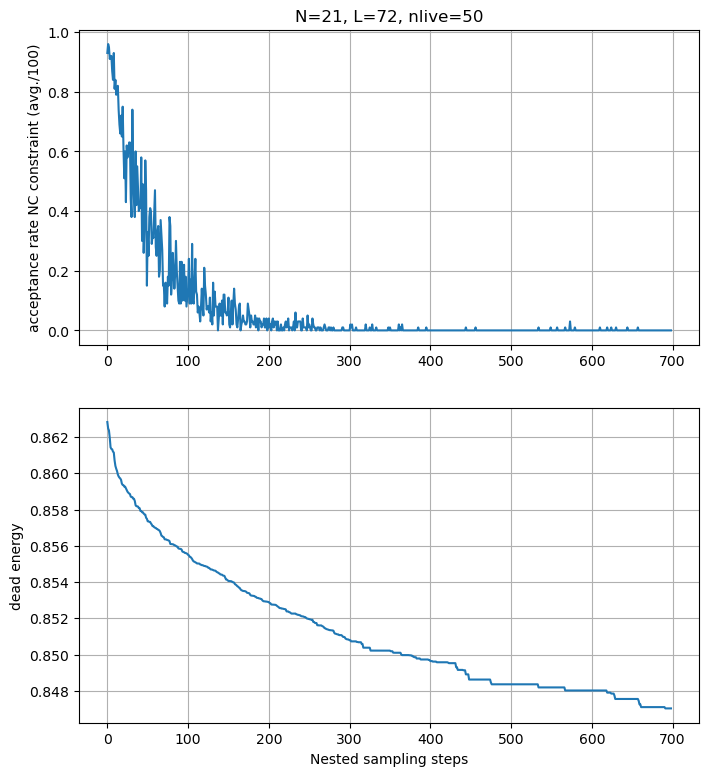

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 9))
axs[0].plot(data[:,1])
axs[0].set_ylabel("acceptance rate NC constraint (avg./100)")
axs[0].grid()
axs[1].plot(data[:,2])
axs[1].set_ylabel("dead energy")
axs[1].grid()

axs[0].set_title("N=21, L=72, nlive=50")
axs[1].set_xlabel("Nested sampling steps")

Text(0.5, 1.0, 'Constraint vs dead E')

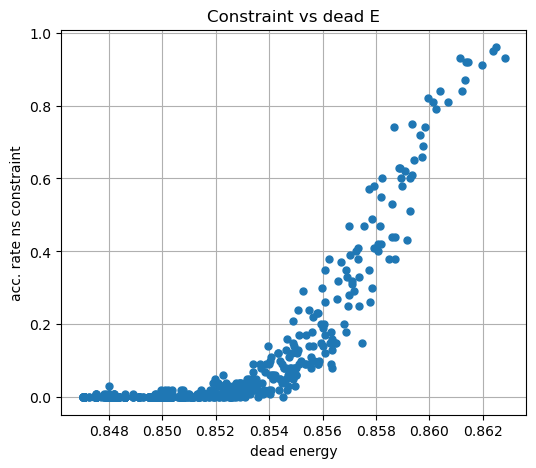

In [39]:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data[:,2], data[:,1], marker="o", markersize=5, linestyle="None")
plt.grid()
plt.xlabel("dead energy")
plt.ylabel("acc. rate ns constraint")
plt.title("Constraint vs dead E")

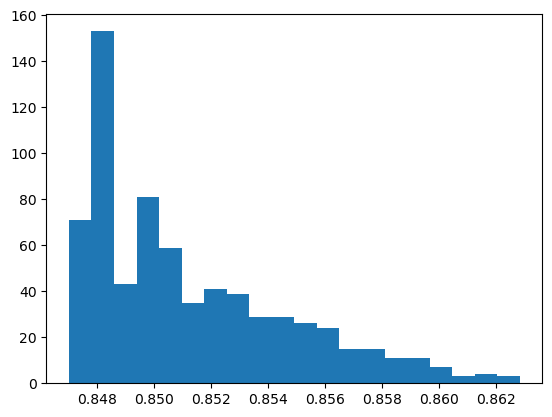

In [40]:
_=plt.hist(data[:,2], bins=20)

# look also at other quantities

similar to the checking_ns_heatbath.ipynb

In [43]:
""" 
the cols in the files are: 
gen_data:
    [0]: Conf. update index
    [1]: energy density S/(2NVb)
    [2]: magn_susc G(p=0)
    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)

topo_data:
    [0]: Conf. update index
    [1]: cooling step
    [2]: geom. top.charge Q_U
    [3]: geom. magn_susc_U
    [4]: geom. top.charge Q_z
    [5]: geom. magn_susc_z
    [6]: non-geom topo charge ~ plaquette
    [7]: non-geom topo susc ~ plaquette
"""

' \nthe cols in the files are: \ngen_data:\n    [0]: Conf. update index\n    [1]: energy density S/(2NVb)\n    [2]: magn_susc G(p=0)\n    [3]: magn_susc G(p=q) => get corr length ~ G(q)/G(0)\n\ntopo_data:\n    [0]: Conf. update index\n    [1]: cooling step\n    [2]: geom. top.charge Q_U\n    [3]: geom. magn_susc_U\n    [4]: geom. top.charge Q_z\n    [5]: geom. magn_susc_z\n    [6]: non-geom topo charge ~ plaquette\n    [7]: non-geom topo susc ~ plaquette\n'

In [47]:
L, T = 72, 72
V = L*T

N = 21
beta = 0.6

n_cool_step = 50     # number of cooling steps 
meas_cool_every = 5
skip_topo = n_cool_step // meas_cool_every + 1

# action prefactor 
pf = 2#beta #*N*V

In [74]:
gen_df  = "dati.dat"
topo_df = "topo.dat"

gen_data = np.loadtxt(os.path.join(ptd,gen_df))
topo_data = np.loadtxt(os.path.join(ptd,topo_df))

In [75]:
print(gen_data.shape, topo_data.shape)

order = np.argsort(gen_data[:,1])[::-1]   # sort after the action vals, from largest to smallest

(700, 4) (7700, 8)


In [76]:
## for gen_data~[N, m], topo_data~[N*skip_topo, k]:
gen_sorted = gen_data[order]

# reshape topo_data into (N, skip_topo, k)
topo_blocks = topo_data.reshape(len(gen_data), skip_topo, -1)

# reorder the blocks
topo_sorted = topo_blocks[order]

# if needed, flatten back to the original shape
topo_sorted = topo_sorted.reshape(-1, topo_data.shape[1])

print(gen_sorted.shape, "\n", topo_sorted.shape)

(700, 4) 
 (7700, 8)


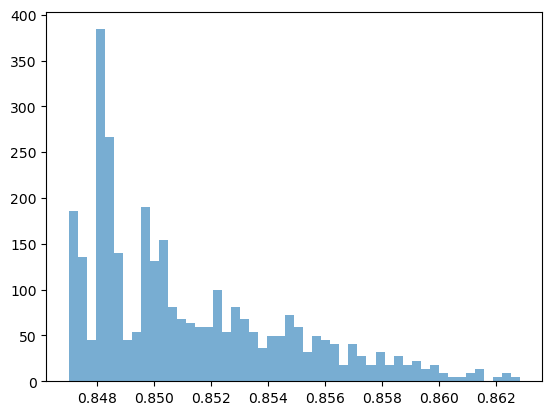

In [77]:
_=plt.hist(gen_sorted[:,1], bins=50, alpha=0.6, density=True)

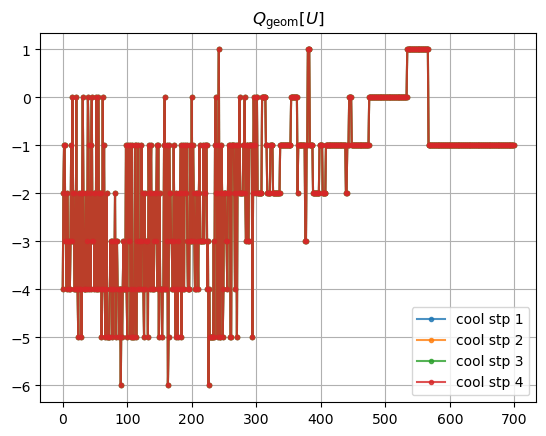

(-5.0, 5.0)

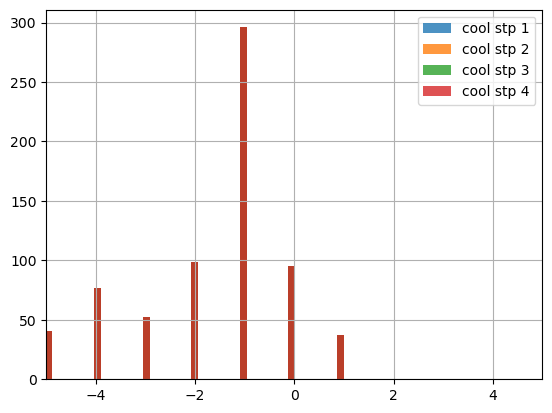

In [78]:
cool_stp = 1    # translates to meas_every_cool... * cool_stp cooling steps
for cool_stp in range(1, 5):
    plt.plot(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, marker="o", ms=3, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.title(r"$Q_\mathrm{geom}[U]$")
plt.show()

for cool_stp in range(1,5):
    plt.hist(topo_sorted[cool_stp::skip_topo,2][:], alpha=0.8, bins=50, label=f"cool stp {cool_stp}")
plt.grid()
plt.legend()
plt.xlim(-5,5)

# compare to the proficiency with two instead of four microcanonical update steps

# and can we also check the efficiency of the von-Neumann-test step?

In [95]:
ptd2 = "out_data/ns_constraint_72_N21_100trials_2/"
data2 = np.loadtxt(os.path.join(ptd2,"acceptance_rate.dat"))
print(data2.shape)

ptd3 = "out_data/ns_constraint_72_N21_100trials_3/"
data3 = np.loadtxt(os.path.join(ptd3,"acceptance_rate.dat"))
print(data3.shape)

(1149, 3)
(574, 5)


Text(0.5, 0, 'Nested sampling steps')

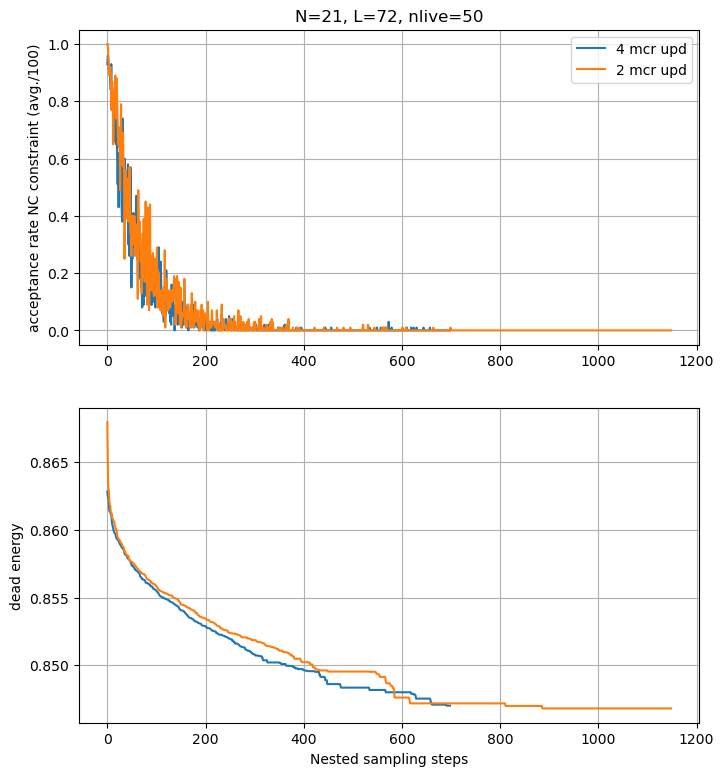

In [96]:
fig, axs = plt.subplots(2, 1, figsize=(8, 9))
axs[0].plot(data[:,1], label="4 mcr upd")
axs[0].plot(data2[:,1], label="2 mcr upd")
axs[0].set_ylabel("acceptance rate NC constraint (avg./100)")
axs[0].grid()
axs[1].plot(data[:,2])
axs[1].plot(data2[:,2])
axs[1].set_ylabel("dead energy")
axs[1].grid()

axs[0].legend()

axs[0].set_title("N=21, L=72, nlive=50")
axs[1].set_xlabel("Nested sampling steps")

Text(0.5, 1.0, 'Constraint vs dead E')

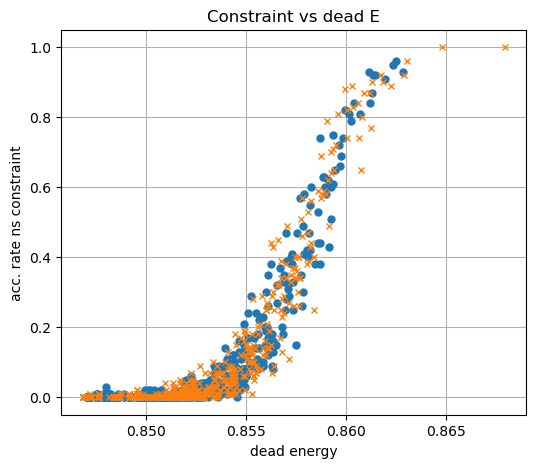

In [97]:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data[:,2], data[:,1], marker="o", markersize=5, linestyle="None")
axs.plot(data2[:,2], data2[:,1], marker="x", markersize=5, linestyle="None")
plt.grid()
plt.xlabel("dead energy")
plt.ylabel("acc. rate ns constraint")
plt.title("Constraint vs dead E")

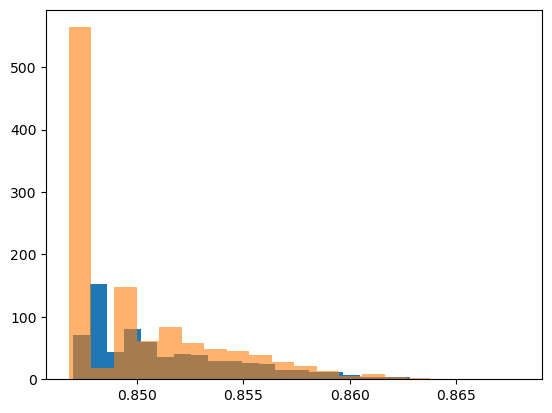

In [98]:
_=plt.hist(data[:,2], bins=20)
_=plt.hist(data2[:,2], bins=20, alpha=0.6)

Text(0.5, 1.0, 'von Neumann efficiency vs dead E (2 micro upd)')

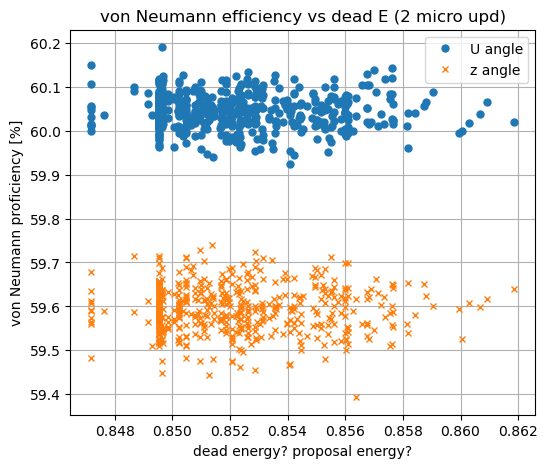

In [93]:
# now also look at the performance of the von Neumann tests:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data3[:,2], 1/data3[:,-2] * 100, marker="o", markersize=5, linestyle="None", label="U angle")
axs.plot(data3[:,2], 1/data3[:,-1] * 100, marker="x", markersize=5, linestyle="None", label="z angle")
plt.grid()
plt.legend()
plt.xlabel("dead energy? proposal energy?")
plt.ylabel("von Neumann proficiency [%]")
plt.title("von Neumann efficiency vs dead E (2 micro upd)")

Text(0.5, 1.0, 'von Neumann efficiency vs dead E (4 micro upd)')

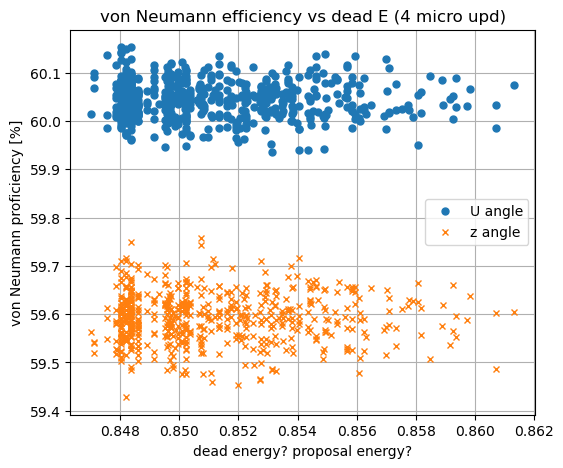

In [99]:
# now also look at the performance of the von Neumann tests:
fig, axs = plt.subplots(1, 1, figsize=(6, 5))
axs.plot(data3[:,2], 1/data3[:,-2] * 100, marker="o", markersize=5, linestyle="None", label="U angle")
axs.plot(data3[:,2], 1/data3[:,-1] * 100, marker="x", markersize=5, linestyle="None", label="z angle")
plt.grid()
plt.legend()
plt.xlabel("dead energy? proposal energy?")
plt.ylabel("von Neumann proficiency [%]")
plt.title("von Neumann efficiency vs dead E (4 micro upd)")